In [1]:
from gekko import GEKKO
import numpy as np
import matplotlib.pyplot as plt  

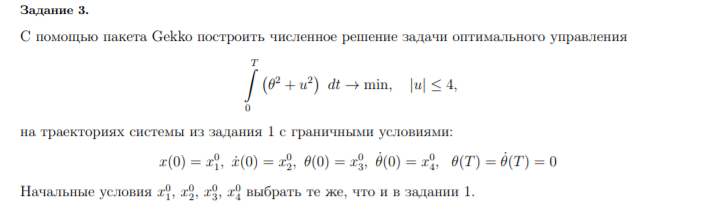

Final Time: 0.10437161061


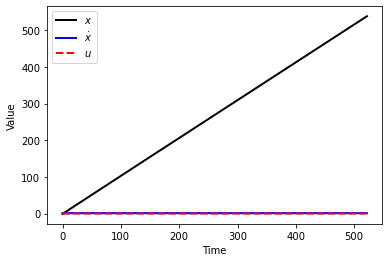

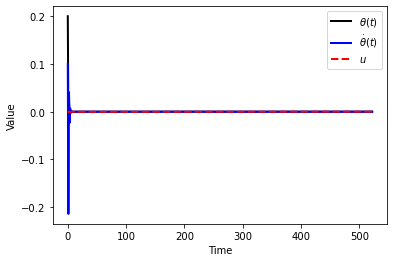

In [4]:
M=4
m=1
L=1
g=9.8
d=(4/6)*M*L + (7/6)*m*L
c11=-g*M*L/(2*d)
c12=7*L/(6*d)
c21=(m+M)*g/d
c22=-1/d

m = GEKKO()

nt = 501
tm = np.linspace(0,5000,nt)
m.time = tm
end_loc = nt-1



# Variables
y0 = m.Var(value=-1)
y1 = m.Var(value=0.2)
y2 = m.Var(value=1)
y3 = m.Var(value=0.1)
y4 = m.Var(value=0.0)
#t = m.Param(value=m.time)

p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# FV
tf = m.FV(value=1.0,lb=0.1,ub=100.0)
tf.STATUS = 1 #The STATUS option set to 1 tells the optimizer that it can be adjusted to minimize the objective

# MV
u = m.MV(fixed_initial=False,lb=-4,ub=4)
u.STATUS = 1 #The STATUS option set to 1 tells the optimizer that it can be adjusted to minimize the objective

m.Equation(y0.dt() == tf*y2)
m.Equation(y1.dt() == tf*y3)
m.Equation(y2.dt() == tf*c11*y1 + tf*c12*u)
m.Equation(y3.dt() == tf*c21*y1 + tf*c22*u)
m.Equation(y4.dt() == tf*(y1**2)+ tf*(u**2))

#m.Equation(y1*final<=0)

m.fix(y1,pos=end_loc,val=0.0)
m.fix(y3,pos=end_loc,val=0.0)

m.Obj(y4*final)



m.options.IMODE = 6
m.solve(disp=False)

print('Final Time: ' + str(tf.value[0]))

tm = tm * tf.value[0]

plt.figure(1)
plt.plot(tm,y0.value,'k-',linewidth=2,label=r'$x$')
plt.plot(tm,y2.value,'b-',linewidth=2,label=r'$\dot x$')
plt.plot(tm,u.value,'r--',linewidth=2,label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


plt.figure(1)
plt.plot(tm,y1.value,'k-',linewidth=2,label=r'$\theta(t)$')
plt.plot(tm,y3.value,'b-',linewidth=2,label=r'$\dot\theta(t)$')
plt.plot(tm,u.value,'r--',linewidth=2,label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()